In [1]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

import pandas as pd

from analysis.metabolite_level_analysis import (
    analyse_with_logistic_regression,
    calculate_odds_ratio,
    calculate_hazard_ratio,
    prepare_duration,
    create_ages_df,
    create_ages_df_with_df
)

from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory,
    MetabolitePathwayCombinedPreprocessorFactory,
    MetaboliteReactionCombinedPreprocessorFactory,
    TranscriptomicsPreprocessorFactory,
    TranscriptomicsMetabolitePreprocessorFactory,
    TranscriptomicsPathwayPreprocessorFactory,
    TranscriptomicsReactionPreprocessorFactory
)

from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


In [6]:
from analysis.cox_regression import compute_hazard_ratios
from analysis import calculate_risk_score_with_best_prs
import pandas as pd

from sklearn.preprocessing import StandardScaler

prs_combined = paths.prs_combined_path
pathway_file_path = paths.pathway_file_path
reaction_file_path = paths.reaction_file_path
metabolite_level_pathway_combined_file_path = paths.metabolite_level_pathway_combined_file_path
metabolite_level_reaction_combined_file_path = paths.metabolite_level_reaction_combined_file_path
x_pathway_path = paths.x_pathway_path
x_reaction_path = paths.x_reaction_path
best_prs_path = paths.best_prs_path
clinical_ages_path = paths.clinical_ages_path

factory_list = [
    MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path),
    PathwayPreprocessorFactory(metabolite_levels_file_path, pathway_file_path, x_pathway_path),
    ReactionPreprocessorFactory(metabolite_levels_file_path, reaction_file_path, x_reaction_path),
    MetabolitePathwayCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_pathway_combined_file_path, x_pathway_path),
    MetaboliteReactionCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_reaction_combined_file_path, x_reaction_path),
]

hazard_ratio_list = {}

for factory in factory_list:
    preprocessor = factory.create_preprocessor()
    print("------------------")
    print(f"Preprocess for: {preprocessor.name}")
    y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
    ages_df = create_ages_df(preprocessor.file_path, clinical_ages_path)
    duration_df = prepare_duration(ages_df)

    hr = compute_hazard_ratios(risk_scores, duration_df)
    hazard_ratio_list[preprocessor.name] = hr

    combined_risk_df = calculate_risk_score_with_best_prs(y, risk_scores, sample_ids_, best_prs_path, prs_combined)
    ages_prs = create_ages_df_with_df(combined_risk_df['sample_id_biomarker'], clinical_ages_path, metabolite_levels_file_path)
    duration_prs = prepare_duration(ages_prs)
    hr_with_prs = compute_hazard_ratios(combined_risk_df['combined_score'], duration_prs)

    hazard_ratio_list[preprocessor.name + " PRS"] = hr_with_prs

prs_df = pd.read_csv(best_prs_path)
scaler = StandardScaler()
prs_df["score"] = scaler.fit_transform(prs_df[["score"]])

ages_prs_ = create_ages_df_with_df(prs_df["sample_id"], clinical_ages_path, metabolite_levels_file_path)
duration_prs_ = prepare_duration(ages_prs_)
hr_prs = compute_hazard_ratios(prs_df['score'], duration_prs_)
hazard_ratio_list["Prs Score PGS001348"] = hr_prs

------------------
Preprocess for: Metabolite Levels
Log(HR) (coef): 0.9568988523014174
Hazard Ratio (exp(coef)): 2.6036097624386474
P-value: 1.1252257555370838e-05
Log(HR) (coef): 0.8664413320692443
Hazard Ratio (exp(coef)): 2.378431726563252
P-value: 0.00010062910667868314
------------------
Preprocess for: Pathway Diff Scores
Log(HR) (coef): 0.7694314900290189
Hazard Ratio (exp(coef)): 2.1585387540906185
P-value: 0.00048394783487012467
Log(HR) (coef): 0.8329947357091604
Hazard Ratio (exp(coef)): 2.3001969178095494
P-value: 0.00027966167856117237
------------------
Preprocess for: Reaction Diff Scores
Log(HR) (coef): 0.9861502348579926
Hazard Ratio (exp(coef)): 2.680893769099462
P-value: 4.41958690387124e-06
Log(HR) (coef): 0.7608987698450639
Hazard Ratio (exp(coef)): 2.1401989025791304
P-value: 0.0006377492763543142
------------------
Preprocess for: Metabolite Levels Pathway Combined
Log(HR) (coef): 1.1782861938662619
Hazard Ratio (exp(coef)): 3.248801612952639
P-value: 5.028235553

In [7]:
print("Preprocessor".ljust(50) + "Odds Ratio")
print("-" * 40)
for name, value in hazard_ratio_list.items():
    print(f"{name}".ljust(50) + f"{value}")

Preprocessor                                      Odds Ratio
----------------------------------------
Metabolite Levels                                 2.6036097624386474
Metabolite Levels PRS                             2.378431726563252
Pathway Diff Scores                               2.1585387540906185
Pathway Diff Scores PRS                           2.3001969178095494
Reaction Diff Scores                              2.680893769099462
Reaction Diff Scores PRS                          2.1401989025791304
Metabolite Levels Pathway Combined                3.248801612952639
Metabolite Levels Pathway Combined PRS            2.0533299212977068
Metabolite Levels Reaction Combined               2.5257622052097823
Metabolite Levels Reaction Combined PRS           2.1401989025791304
Prs Score PGS001348                               1.3013475755617228


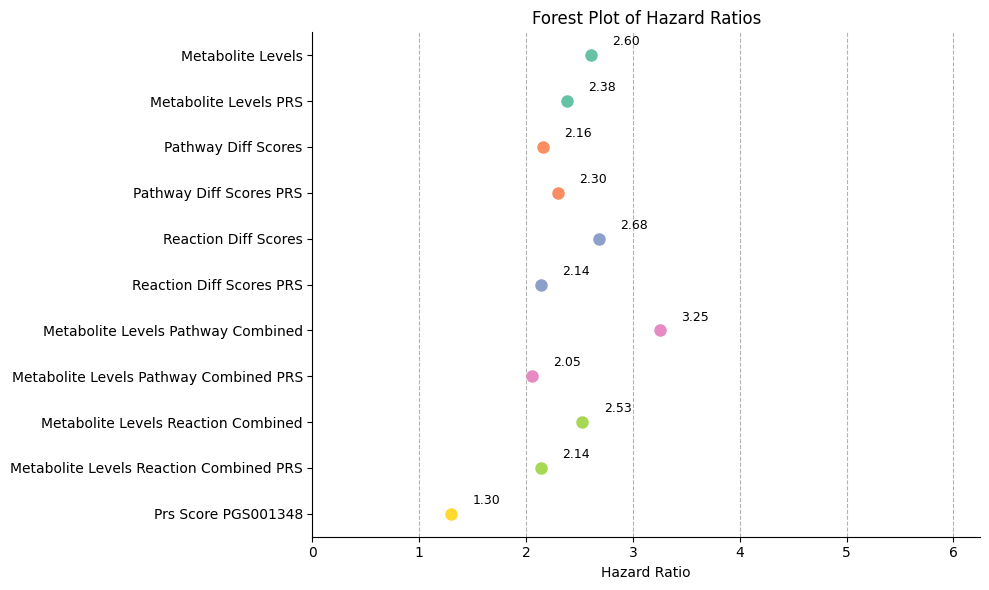

In [8]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(hazard_ratio_list.keys())
odds_ratios = np.array(list(hazard_ratio_list.values()))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')         # Set axes background to white

y_pos = np.arange(len(labels))
colors = plt.cm.Set2.colors  # Light, pastel colors

for i, (odds, label) in enumerate(zip(odds_ratios, labels)):
    color = colors[(i // 2) % len(colors)]  # Use same color for pairs (0-1, 2-3, ...)
    ax.plot(odds, y_pos[i], 'o', color=color, markersize=8)
    ax.text(odds + 0.2, y_pos[i] - 0.15, f"{odds:.2f}",
            va='bottom', ha='left', fontsize=9, color='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, color='black')
ax.invert_yaxis()
ax.set_xlabel("Hazard Ratio", color='black')
ax.set_title("Forest Plot of Hazard Ratios", color='black')
ax.set_xlim(0, max(odds_ratios) + 3)

# Only vertical grid lines
ax.grid(True, axis='x', linestyle='--', alpha=0.6, color='gray')

# Optional: remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(colors='black')

plt.tight_layout()
plt.show()


In [12]:
from analysis.cox_regression import compute_hazard_ratios
from analysis import calculate_risk_score_with_best_prs
factory = MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path)
preprocessor = factory.create_preprocessor()
y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
ages_df = create_ages_df(preprocessor.file_path, clinical_ages_path)
duration_df = prepare_duration(ages_df)

hr = compute_hazard_ratios(risk_scores, duration_df)

# combined__df = calculate_risk_score_with_best_prs(y, risk_scores, sample_ids_)


Log(HR) (coef): 0.9568988523014174
Hazard Ratio (exp(coef)): 2.6036097624386474
P-value: 1.1252257555370838e-05
